# ipynb/loc_compare_nofont_gen3.ipynb - 定位对比(3Gen,无字体) / Localization compare (3Gen, no font)

## 项目背景 / Background
定位对比(3Gen,无字体)
Localization compare (3Gen, no font)

## 功能模块 / Modules
- 3Gen 物种定位对比
- (详见各代码单元 / see code cells)

## 输入 / Inputs
- 上一阶段产物(.npy/.pt/.csv/.json)/ prior-stage outputs
- 内嵌常量与参数 / inline constants and params

## 输出 / Outputs
- 图表(内联显示) / figures (inline)
- 中间变量 / intermediate variables
- 导出文件(.png/.pdf/.csv) / exported files

## 数据流 / Data Flow
1. 加载数据 / Load data
2. 运行分析 / Run analysis
3. 渲染图表 / Render figures
4. 导出 / Export

## 相关文件 / Related Files
- 调用 / Calls: dataset/gen3.py、ipynb/loc_compare_nofont.ipynb
- 被调用 / Called by: 报告 / 论文 / report / paper

## 使用示例 / Usage Example
- 在 JupyterLab 中打开 / open in JupyterLab
- 逐单元运行 / run cells sequentially

## 作者 / Author
项目组 / Project Team

## 版本 / Version
1.0



Warning message in geom_arc_bar(data = plot_data, aes(x0 = Metric_num, y0 = Class_num, :
“Ignoring unknown parameters: `linejoin`”
Warning message in geom_arc_bar(data = ref_df, aes(x0 = x, y0 = y, r0 = 0, r = r_inner, :
“Ignoring unknown parameters: `linejoin`”


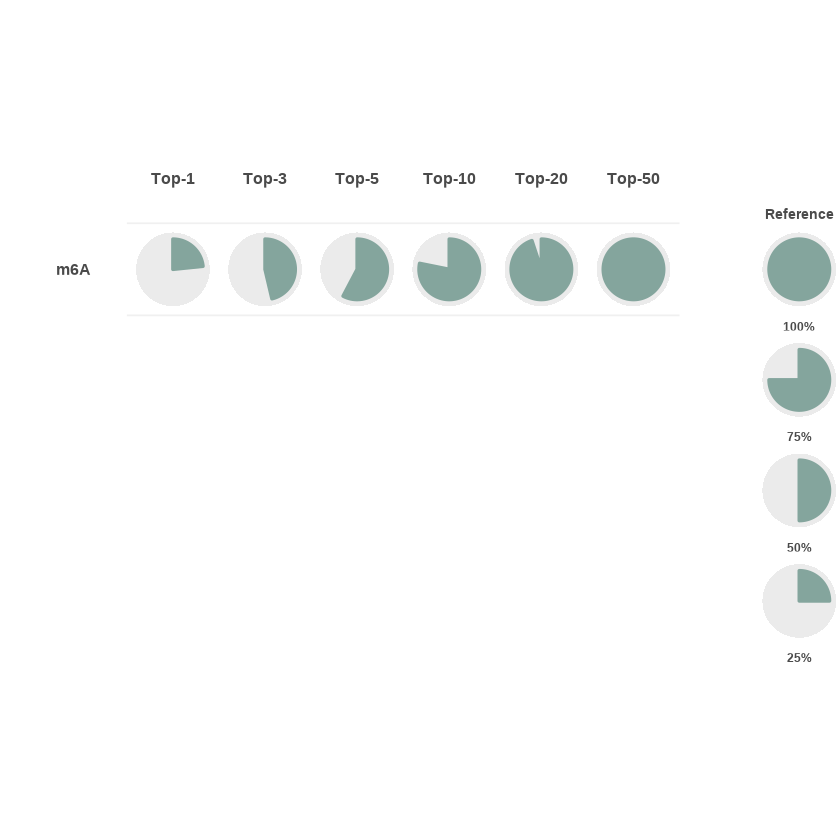

In [2]:
# ==========================================
# 1. 环境配置与字体加载
# ==========================================
library(showtext)
library(ggplot2)
library(dplyr)
library(tidyr)
library(ggforce)

# 开启字体支持
showtext_auto()

# ==========================================
# 2. 全局参数设置 (保持与 loc_compare_nofont.ipynb 一致)
# ==========================================
unified_radius <- 0.40     # 所有饼图的统一半径
gap_ratio      <- 0.82     # 内部进度相对于底圆的比例
ref_spacing    <- 1.2      # Reference 示意图内部的垂直间距
font_size      <- 12       # 轴文字大小

r_outer <- unified_radius
r_inner <- unified_radius * gap_ratio

# 莫兰迪配色方案 (与 loc_compare_nofont.ipynb 一致)
morandi_palette <- list(
  bg_circle   = "#EBEBEB",  # 饼图底色
  pie_fill    = "#84A59D",  # 饼图填充色
  text_dark   = "#4A4A4A",  # 文字颜色
  grid_line   = "#F0F0F0"   # 水平分割线
)

# ==========================================
# 3. 数据预处理 - 只读取 m6A 数据
# ==========================================

# A. 读取 gen3 数据并筛选 m6A
df_gen3 <- read.csv("gen3_data/gen3.csv", check.names = FALSE)
df_m6a <- df_gen3 %>%
  filter(Name == "m6A") %>%
  select(-Class)

# B. 定义 k 值层级
k_levels <- c("Top-1", "Top-3", "Top-5", "Top-10", "Top-20", "Top-50")
n_k <- length(k_levels)
n_classes <- 1  # 只有 m6A 一行

# C. 处理主图数据
class_levels <- "m6A"
plot_data <- df_m6a %>%
  pivot_longer(cols = all_of(k_levels), names_to = "Metric", values_to = "Value") %>%
  mutate(
    Metric_num = as.numeric(factor(Metric, levels = k_levels)),
    Class_num = 1  # m6A 放在第一行
  )

# D. 建立 Reference 专用坐标 (在主图 X 轴外)
ref_x_pos <- n_k + 1.8
ref_df <- data.frame(
  x = rep(ref_x_pos, 4),
  y = c(1, 1 - ref_spacing, 1 - ref_spacing * 2, 1 - ref_spacing * 3),
  val = c(1.00, 0.75, 0.50, 0.25),
  label = c("100%", "75%", "50%", "25%")
)

# ==========================================
# 4. 核心绘图逻辑
# ==========================================

p <- ggplot() +
  # A. 水平分割线
  annotate("segment",
           x = 0.5, xend = n_k + 0.5,
           y = seq(0.5, n_classes + 0.5, 1),
           yend = seq(0.5, n_classes + 0.5, 1),
           color = morandi_palette$grid_line, linewidth = 0.5) +

  # B. 主图：双层圆角饼图 (底圆 + 进度圆)
  geom_arc_bar(data = plot_data,
               aes(x0 = Metric_num, y0 = Class_num, r0 = 0, r = r_outer, start = 0, end = 2*pi),
               fill = morandi_palette$bg_circle, color = NA) +
  geom_arc_bar(data = plot_data,
               aes(x0 = Metric_num, y0 = Class_num, r0 = 0, r = r_inner, start = 0, end = Value * 2 * pi),
               fill = morandi_palette$pie_fill, color = morandi_palette$pie_fill,
               linewidth = 1, linejoin = "round") +

  # C. Reference 组件 (渲染在右侧)
  annotate("text", x = ref_x_pos, y = max(ref_df$y) + 0.6, label = "Reference",
           size = font_size/3.2, fontface = "bold", color = morandi_palette$text_dark) +
  geom_arc_bar(data = ref_df,
               aes(x0 = x, y0 = y, r0 = 0, r = r_outer, start = 0, end = 2*pi),
               fill = morandi_palette$bg_circle, color = NA) +
  geom_arc_bar(data = ref_df,
               aes(x0 = x, y0 = y, r0 = 0, r = r_inner, start = 0, end = val * 2 * pi),
               fill = morandi_palette$pie_fill, color = morandi_palette$pie_fill,
               linewidth = 1, linejoin = "round") +
  # Reference 标签
  geom_text(data = ref_df,
            aes(x = x, y = y - (r_outer + 0.22), label = label),
            size = font_size/3.8, fontface = "bold", color = morandi_palette$text_dark) +

  # D. 坐标系控制
  coord_fixed(ratio = 1, xlim = c(0.5, n_k + 0.5), clip = "off") +
  scale_x_continuous(breaks = 1:n_k, labels = k_levels, position = "top") +
  scale_y_continuous(breaks = 1:n_classes, labels = class_levels) +

  # E. 主题设置
  theme_minimal() +
  theme(
    axis.title = element_blank(),
    axis.text = element_text(size = font_size, face = "bold", color = morandi_palette$text_dark),
    panel.grid = element_blank(),
    plot.margin = margin(20, 80, 20, 20)
  )

# ==========================================
# 5. 保存图表
# ==========================================
# 创建输出目录
dir.create("gen3_png", showWarnings = FALSE)

# 保存为 PDF
ggsave("gen3_png/m6a_performance.pdf", p, width = 10, height = 3, device = cairo_pdf)

# 保存为 PNG
ggsave("gen3_png/m6a_performance.png", p, width = 10, height = 3, dpi = 300)

print(p)